In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

### Box plot do clima por região: 

In [2]:
update_prof = {'Episódico/Epidêmico':'Episodic/Epidemic', 'Epidêmico':'Epidemic', 'Episódico':'Episodic',
       'Transmissão Persistente':'Persistent Transmission', 'Sem transmissão': 'No Transmission', 
              'Sem transmissao': 'No Transmission'}

In [3]:

code_to_state = {33: 'RJ', 32: 'ES', 41: 'PR', 23: 'CE', 21: 'MA',
 31: 'MG', 42: 'SC', 26: 'PE', 25: 'PB', 24: 'RN', 22: 'PI', 27: 'AL',
 28: 'SE', 35: 'SP', 43: 'RS', 15: 'PA', 16: 'AP', 14: 'RR',  11: 'RO',
 13: 'AM', 12: 'AC', 51: 'MT', 50: 'MS', 52: 'GO', 17: 'TO', 53: 'DF',
 29: 'BA'}

state_to_region = {'SC':'Sul', 'PR':'Sul', 'RS':'Sul',
                  'SP':'Sudeste', 'MG':'Sudeste', 'RJ':'Sudeste', 'ES':'Sudeste',
                  'BA':'Nordeste', 'CE':'Nordeste', 'PE':'Nordeste', 'PB':'Nordeste', 'PI':'Nordeste',
                   'RN':'Nordeste', 'MA':'Nordeste', 'AL':'Nordeste', 'SE':'Nordeste',
                  'DF':'Centro - Oeste', 'MT':'Centro - Oeste', 'MS':'Centro - Oeste', 'GO':'Centro - Oeste',
                  'RO':'Norte', 'AC':'Norte', 'AM':'Norte', 'RR':'Norte', 'PA':'Norte', 'AP':'Norte', 'TO':'Norte'}

rename_region = {'Sul': 'South', 'Sudeste':'Southeast','Centro - Oeste': 'Midwest', 'Norte':'North', 'Nordeste':'Northeast'}

In [4]:
df_10_16 = pd.read_csv('../Determinantes/clima/clima_agg_10_16.csv', index_col = 'Unnamed: 0')

df_10_16.loc[:, 'dengue_pattern'] = df_10_16.dengue_pattern.replace(update_prof)

df_10_16['period'] = '10_16'

df_10_16['region'] = df_10_16['geocodigo'].astype(str).str[:2].astype(int).replace(code_to_state).replace(state_to_region)

df_10_16['region'] = df_10_16['region'].replace(rename_region)

df_10_16.head()

,geocodigo,temp_med,umid_med,precip_tot,thr_temp,thr_umid,thr_prec,thr_temp_umid,year,dengue_pattern,period,region
0,2700102,25.917411,71.160050,174.737289,364,314,2,314,2010,Episodic/Epidemic,10_16,Northeast
1,2700201,25.484200,80.407899,424.205669,364,364,5,364,2010,Episodic/Epidemic,10_16,Northeast
2,2700300,25.588142,77.216115,277.945870,364,364,2,364,2010,Epidemic,10_16,Northeast
3,2700409,24.897218,81.989589,423.138619,364,364,4,364,2010,Episodic/Epidemic,10_16,Northeast
4,2700508,25.800147,78.780638,491.421552,364,363,5,363,2010,Episodic,10_16,Northeast


In [5]:
df_10_16.dengue_pattern.value_counts()/df_10_16.shape[0]

dengue_pattern
Episodic/Epidemic          0.521903
Episodic                   0.309156
Epidemic                   0.115260
No Transmission            0.051346
Persistent Transmission    0.002334
Name: count, dtype: float64

In [6]:
df_17_22 = pd.read_csv('../Determinantes/clima/clima_agg_17_22.csv', index_col = 'Unnamed: 0')

df_17_22.loc[:, 'dengue_pattern'] = df_17_22.dengue_pattern.replace(update_prof)

df_17_22['period'] = '17_22'

df_17_22['region'] = df_17_22['geocodigo'].astype(str).str[:2].astype(int).replace(code_to_state).replace(state_to_region)

df_17_22['region'] = df_17_22['region'].replace(rename_region)

df_17_22.dengue_pattern.value_counts()/df_17_22.shape[0]

dengue_pattern
Episodic/Epidemic          0.506463
Episodic                   0.330521
Epidemic                   0.130341
No Transmission            0.026930
Persistent Transmission    0.005745
Name: count, dtype: float64

In [7]:
df = pd.concat([df_10_16, df_17_22])

df.head()

,geocodigo,temp_med,umid_med,precip_tot,thr_temp,thr_umid,thr_prec,thr_temp_umid,year,dengue_pattern,period,region
0,2700102,25.917411,71.160050,174.737289,364,314,2,314,2010,Episodic/Epidemic,10_16,Northeast
1,2700201,25.484200,80.407899,424.205669,364,364,5,364,2010,Episodic/Epidemic,10_16,Northeast
2,2700300,25.588142,77.216115,277.945870,364,364,2,364,2010,Epidemic,10_16,Northeast
3,2700409,24.897218,81.989589,423.138619,364,364,4,364,2010,Episodic/Epidemic,10_16,Northeast
4,2700508,25.800147,78.780638,491.421552,364,363,5,363,2010,Episodic,10_16,Northeast


In [8]:
df.isnull().sum()

geocodigo         0
temp_med          0
umid_med          0
precip_tot        0
thr_temp          0
thr_umid          0
thr_prec          0
thr_temp_umid     0
year              0
dengue_pattern    0
period            0
region            0
dtype: int64

In [9]:
df.region.unique()

array(['Northeast', 'Southeast', 'North', 'Midwest', 'South'],
      dtype=object)

In [10]:
prof_order = ['No Transmission', 'Episodic', 'Episodic/Epidemic', 'Epidemic', 
       'Persistent Transmission']

In [11]:
def make_box(df, region): 

    df = df.loc[df.region == region]
    fig, ax = plt.subplots(3,1, figsize = (9, 8),  sharex = True)

    sns.boxplot(x='dengue_pattern', y='temp_med', data=df, showfliers = False, order = prof_order, hue = 'period', ax=ax[0],
               notch = True)
    
    sns.boxplot(y='temp_med', data=df, showfliers = False, hue = 'period', ax=ax[0],
               notch = True, palette = ['tab:blue','tab:orange'], legend = False)
    
    ax[0].set_ylabel('Average \n temperature')
    
    ax[0].grid(True, axis='y')
    
    sns.boxplot(x='dengue_pattern', y='umid_med', data=df, showfliers = False,order = prof_order,  hue = 'period',ax=ax[1],notch = True, legend = False)
    
    sns.boxplot(y='umid_med', data=df, showfliers = False, hue = 'period', ax=ax[1],
               notch = True, palette = ['tab:blue','tab:orange'], legend = False)
    
    ax[1].set_ylabel('Average \n humidity')
    
    ax[1].grid(True, axis='y')
    
    
    sns.boxplot(x='dengue_pattern', y='precip_tot', data=df, showfliers = False,order = prof_order, hue = 'period', ax=ax[2],notch = True, legend = False)
    
    sns.boxplot(y='precip_tot', data=df, showfliers = False,  hue = 'period', ax=ax[2],
               notch = True, palette = ['tab:blue','tab:orange'], legend = False)
    
    ax[2].set_ylabel('Total \n precipitation')
    
    ax[2].grid(True, axis='y')
    
    
    plt.suptitle(f'Boxplot of climatic variables grouped by \n dengue pattern and epidemiological year - {region}')
    
    for ax_ in [ax[0], ax[1], ax[2]]:
    
        ax_.set_xticklabels(list(prof_order) + ['All'])
        ax_.set_xlabel('Dengue pattern')
    
    ax[0].legend(title = 'Period', loc='upper right', bbox_to_anchor = (1.15, 1))
    
    
    plt.tight_layout()
    plt.xticks(rotation=15)  # Rotate x labels if needed
    
    plt.savefig(f'../figures/boxplot_clima_{region}.png',  dpi = 300, bbox_inches = 'tight')
    plt.show()

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


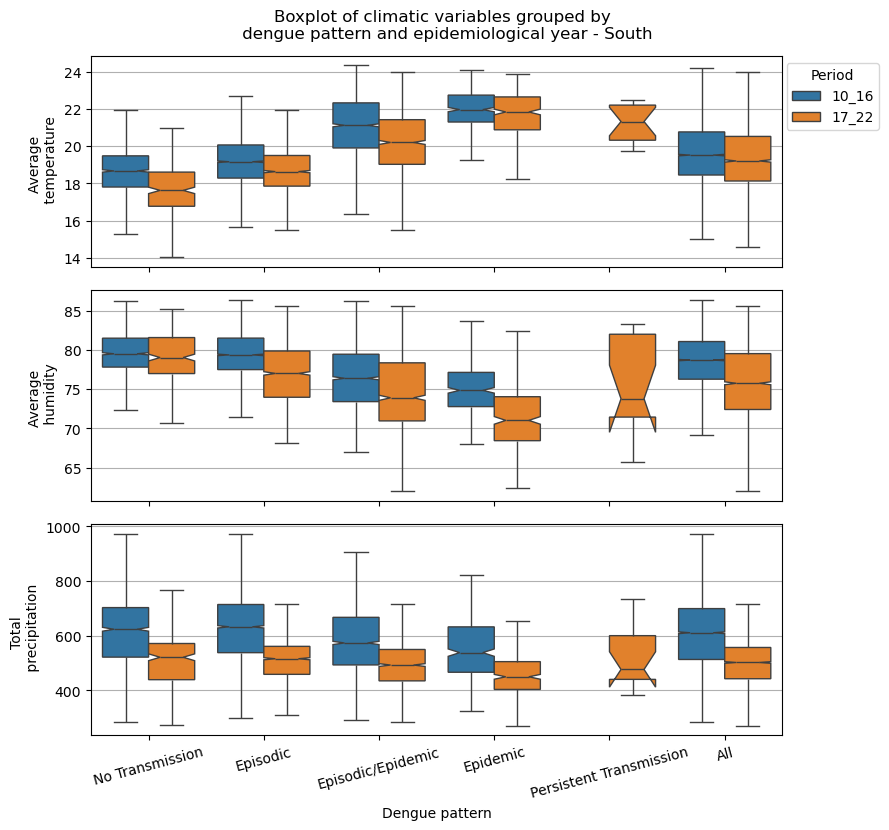

In [12]:
make_box(df, region= 'South')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


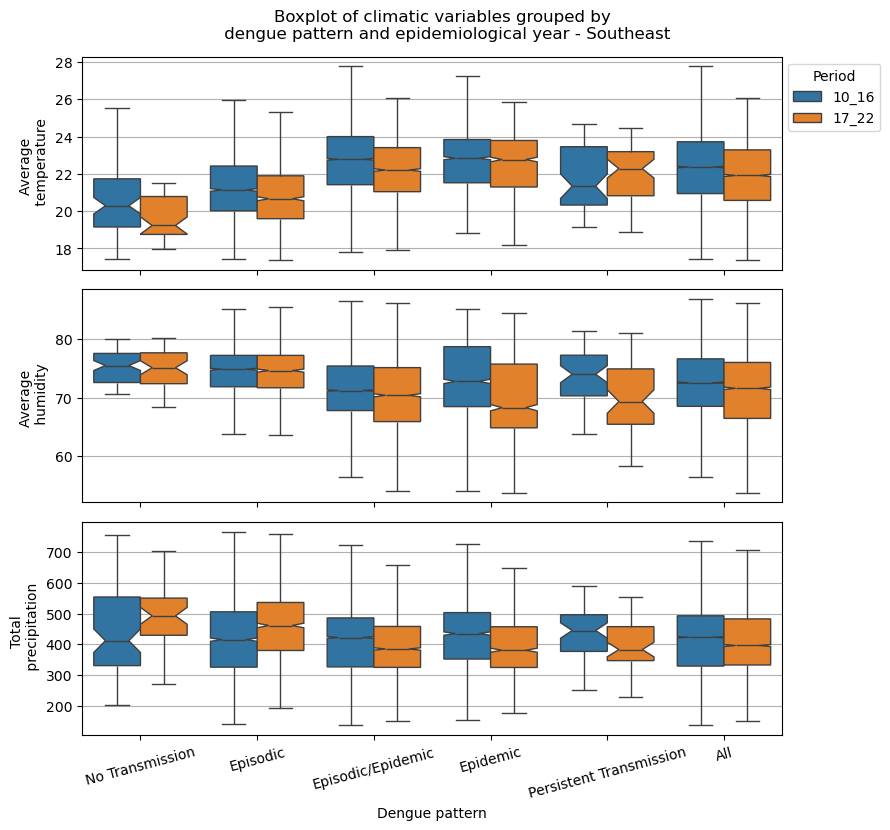

In [13]:
make_box(df, region= 'Southeast')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


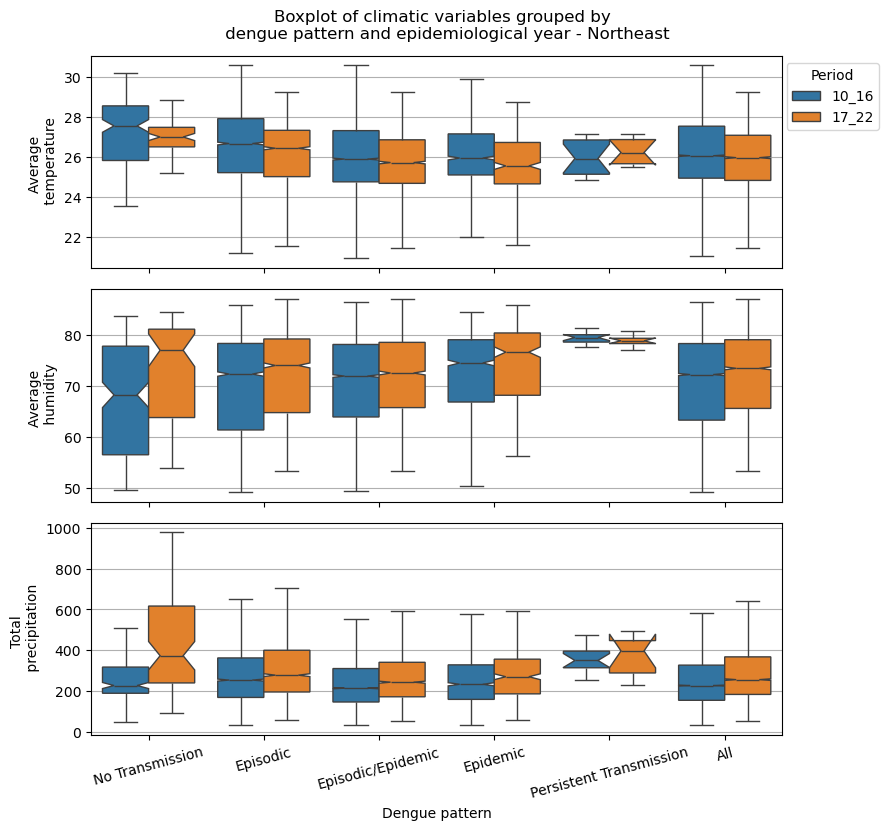

In [14]:
make_box(df, region= 'Northeast')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


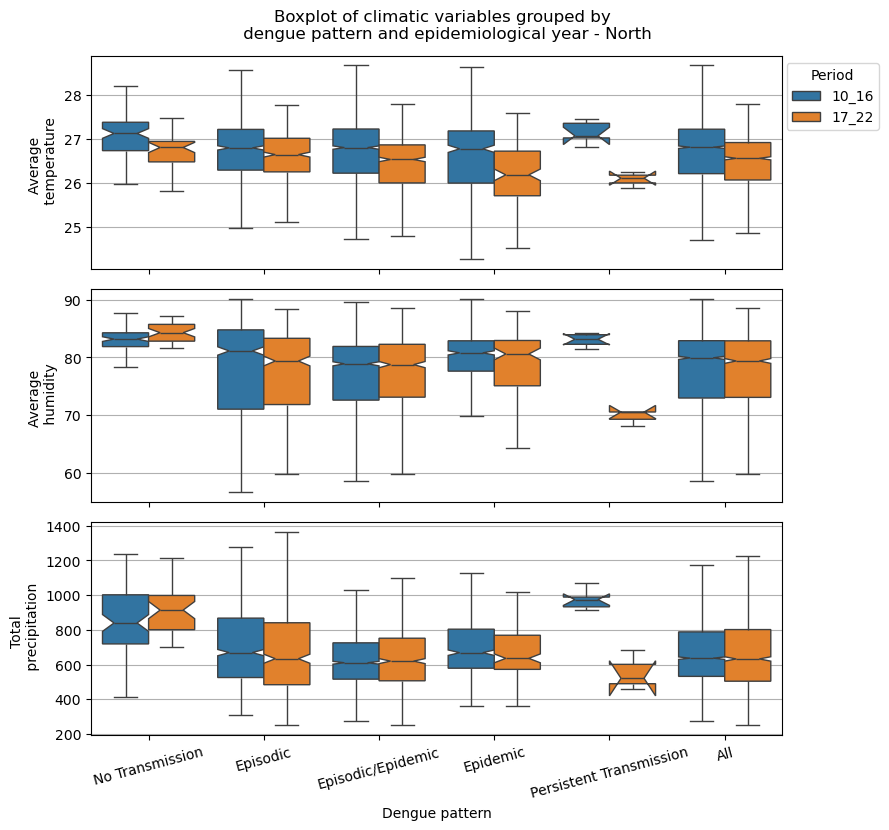

In [15]:
make_box(df, region= 'North')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3194167311.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


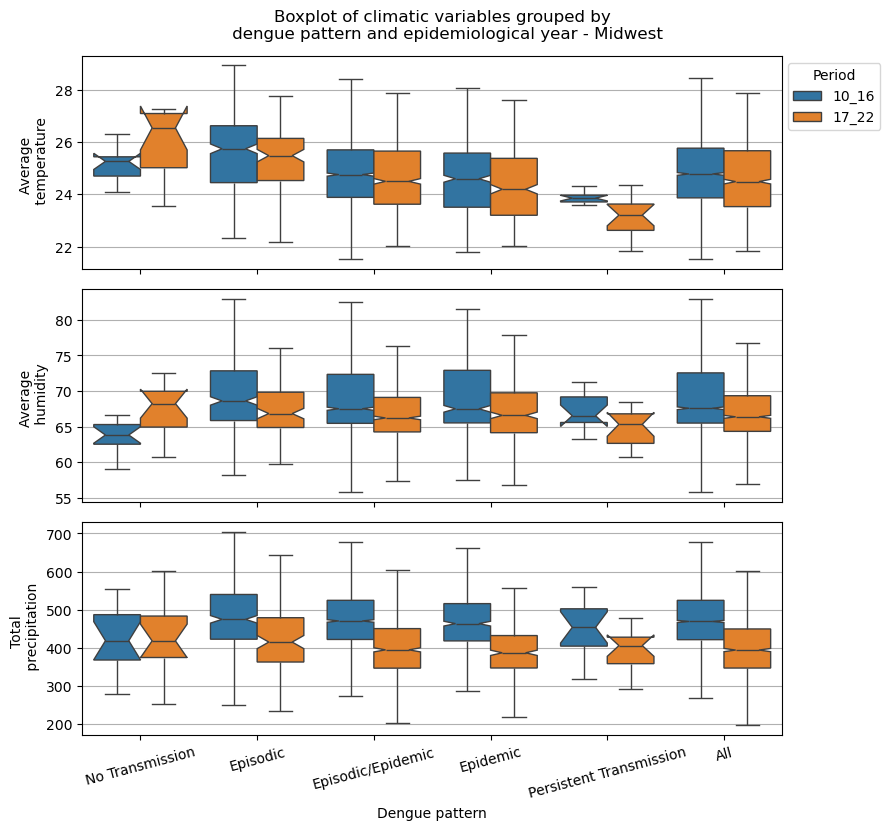

In [16]:
make_box(df, region= 'Midwest')

In [17]:
def make_box_thr(df, region): 

    df = df.loc[df.region == region]
    fig, ax = plt.subplots(2,2, figsize = (15, 8),  sharex = True)

    sns.boxplot(x='dengue_pattern', y='thr_temp', data=df, showfliers = False, order = prof_order, hue = 'period', ax=ax[0,0],
               notch = True)
    
    sns.boxplot(y='thr_temp', data=df, showfliers = False, hue = 'period', ax=ax[0,0],
               notch = True, palette = ['tab:blue','tab:orange'], legend = False)
    
    ax[0,0].set_ylabel('Average number of days with temp > 20°C')
    
    ax[0,0].grid(True, axis='y')
    
    sns.boxplot(x='dengue_pattern', y='thr_temp_umid', data=df, showfliers = False,order = prof_order,  hue = 'period',ax=ax[0,1],notch = True, legend = False)
    
    sns.boxplot(y='thr_temp_umid', data=df, showfliers = False, hue = 'period', ax=ax[0,1],
               notch = True, palette = ['tab:blue','tab:orange'], legend = False)
    
    ax[0,1].set_ylabel('temp > 20°C & umid > 60%')
    
    ax[0,1].grid(True, axis='y')
    
    sns.boxplot(x='dengue_pattern', y='thr_prec', data=df, showfliers = False,order = prof_order, hue = 'period', ax=ax[1,0],notch = True, legend = False)
    
    sns.boxplot(y='thr_prec', data=df, showfliers = False,  hue = 'period', ax=ax[1,0],
               notch = True, palette = ['tab:blue','tab:orange'], legend = False)
    
    ax[1,0].set_ylabel('Prec > 10mm')
    
    ax[1,0].grid(True, axis='y')

    sns.boxplot(x='dengue_pattern', y='thr_umid', data=df, showfliers = False,order = prof_order, hue = 'period', ax=ax[1,1],notch = True, legend = False)
    
    sns.boxplot(y='thr_umid', data=df, showfliers = False,  hue = 'period', ax=ax[1,1],
               notch = True, palette = ['tab:blue','tab:orange'], legend = False)
    
    ax[1,1].set_ylabel('umid > 60%')
    
    ax[1,1].grid(True, axis='y')
    
    plt.suptitle(f'Boxplot of averaged days of favorable climate conditions grouped by \n dengue pattern and epidemiological year {region}')
        
    for ax_ in ax.ravel():
    
        ax_.set_xticklabels(list(prof_order) + ['All'])
        ax_.set_xlabel('Dengue pattern')    
    
    plt.tight_layout()
    plt.xticks(rotation=15)  # Rotate x labels if needed
    
    plt.savefig(f'../figures/boxplot_clima_thr_{region}.png',  dpi = 300, bbox_inches = 'tight')
    plt.show()

In [18]:
df.head()

,geocodigo,temp_med,umid_med,precip_tot,thr_temp,thr_umid,thr_prec,thr_temp_umid,year,dengue_pattern,period,region
0,2700102,25.917411,71.160050,174.737289,364,314,2,314,2010,Episodic/Epidemic,10_16,Northeast
1,2700201,25.484200,80.407899,424.205669,364,364,5,364,2010,Episodic/Epidemic,10_16,Northeast
2,2700300,25.588142,77.216115,277.945870,364,364,2,364,2010,Epidemic,10_16,Northeast
3,2700409,24.897218,81.989589,423.138619,364,364,4,364,2010,Episodic/Epidemic,10_16,Northeast
4,2700508,25.800147,78.780638,491.421552,364,363,5,363,2010,Episodic,10_16,Northeast


/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.

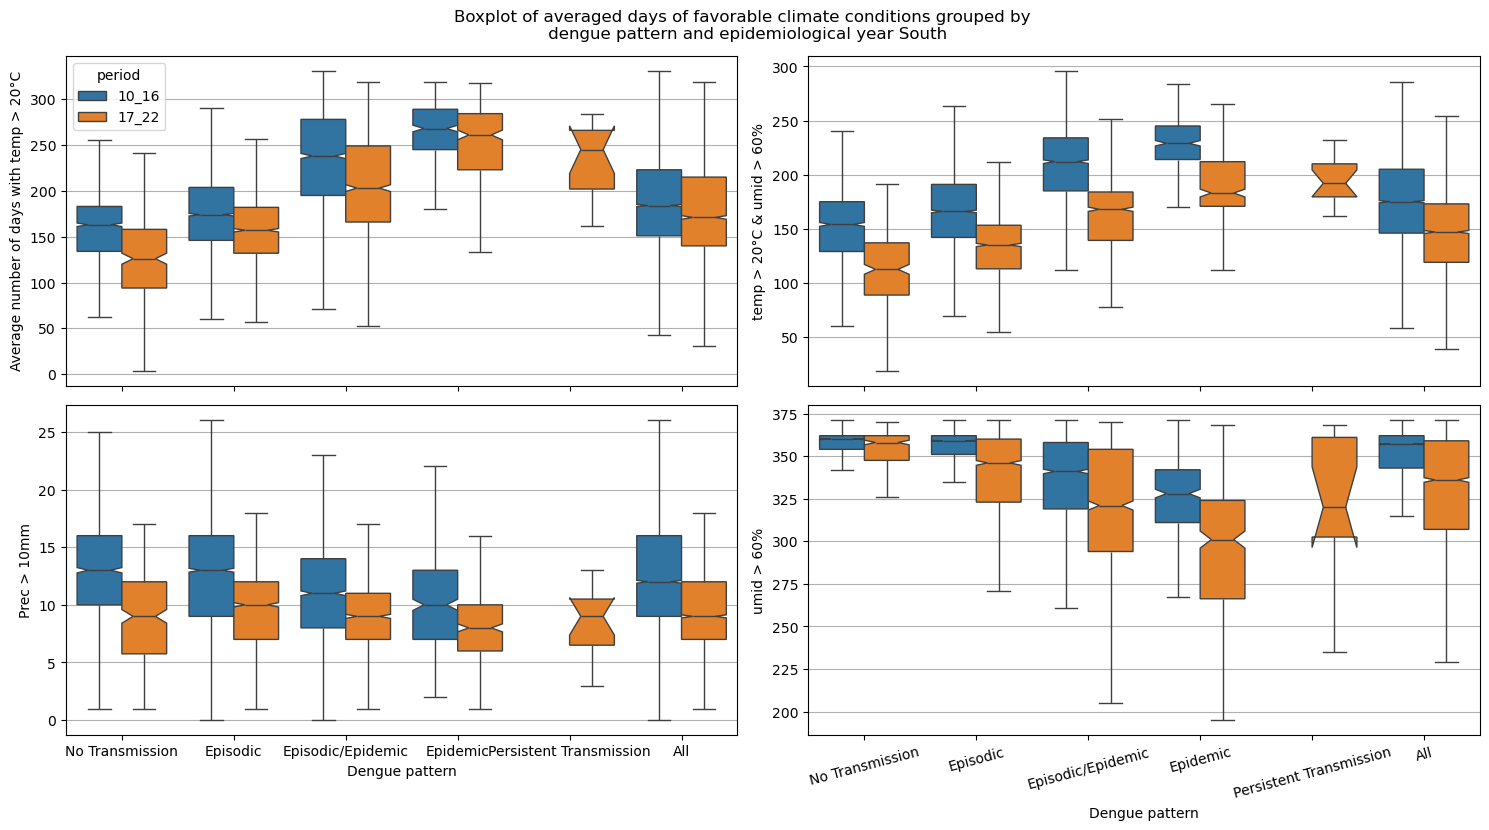

In [19]:
make_box_thr(df, region='South')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.

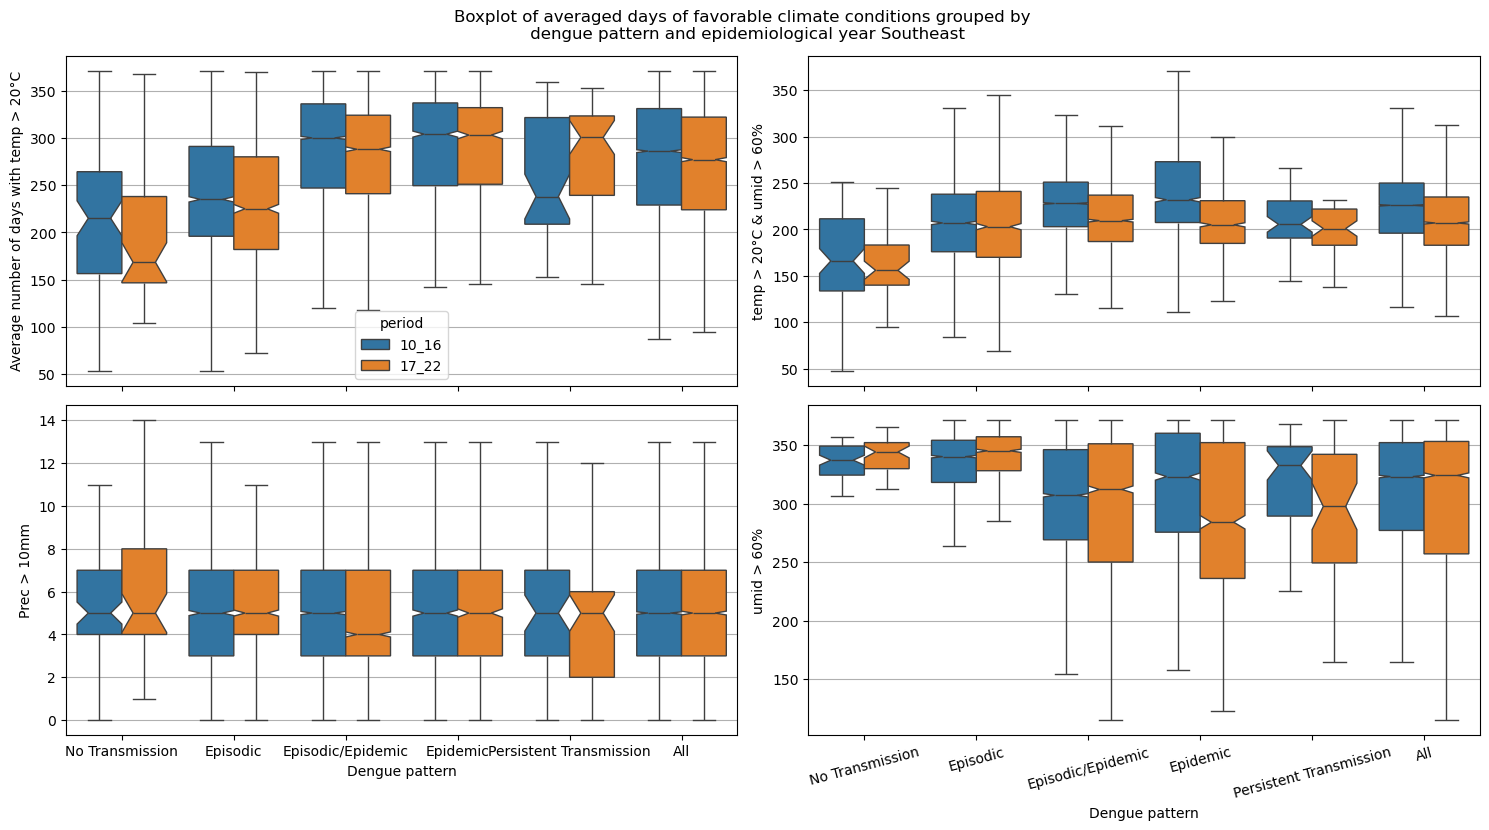

In [20]:
make_box_thr(df, region='Southeast')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.

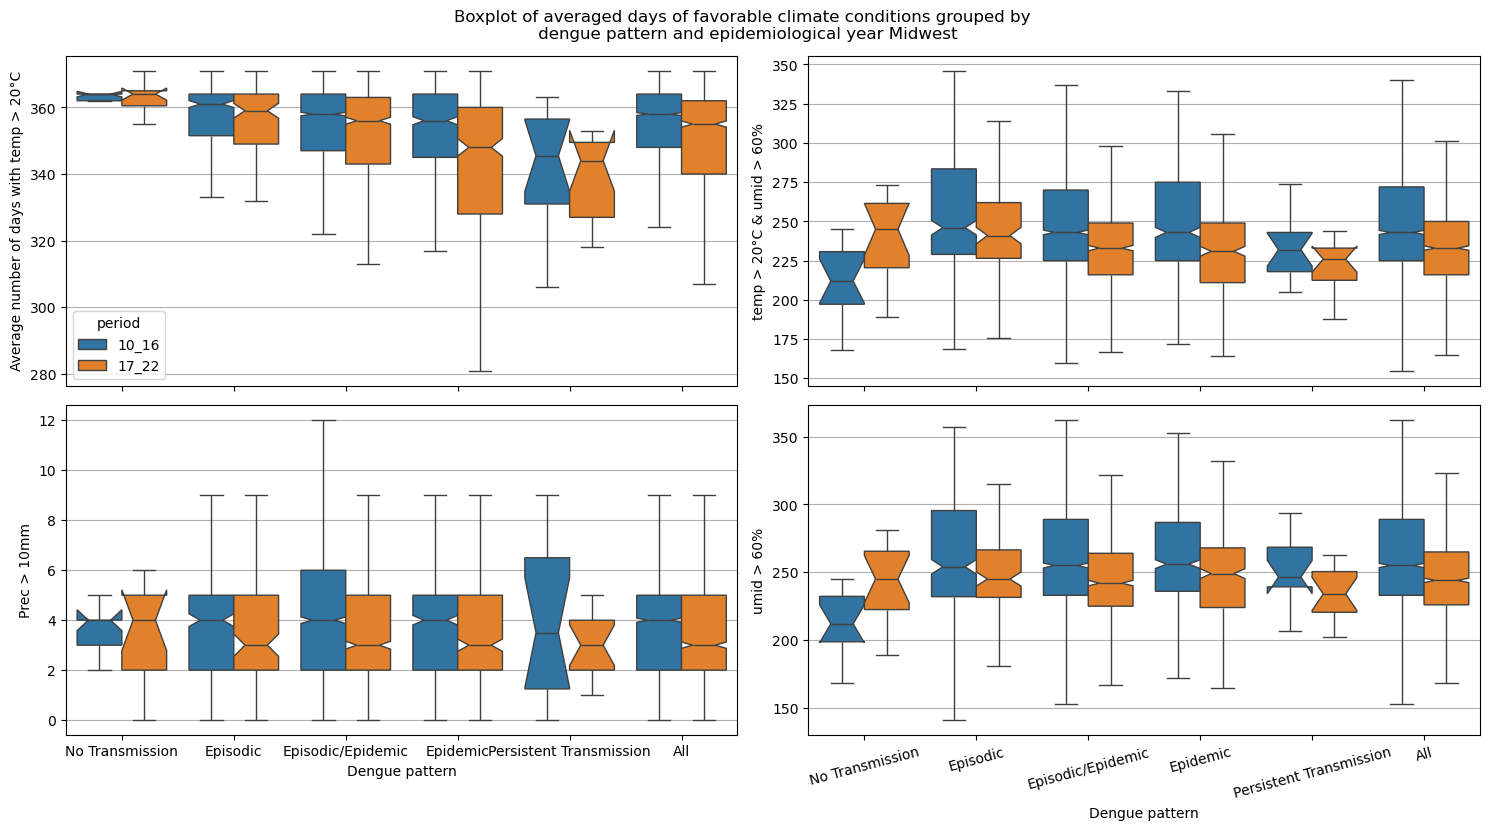

In [21]:
make_box_thr(df, region='Midwest')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.

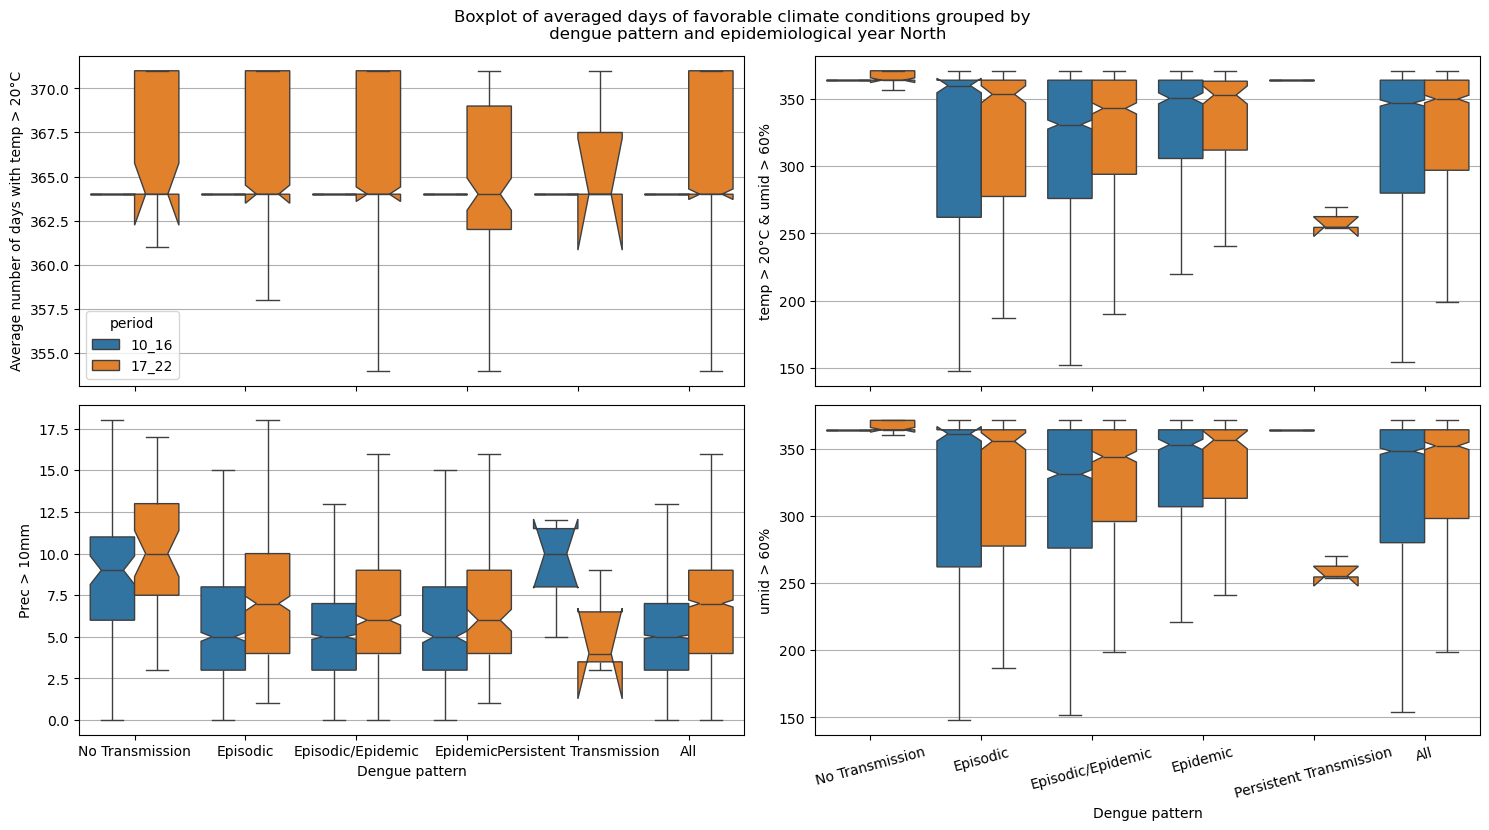

In [22]:
make_box_thr(df, region='North')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3606943141.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.

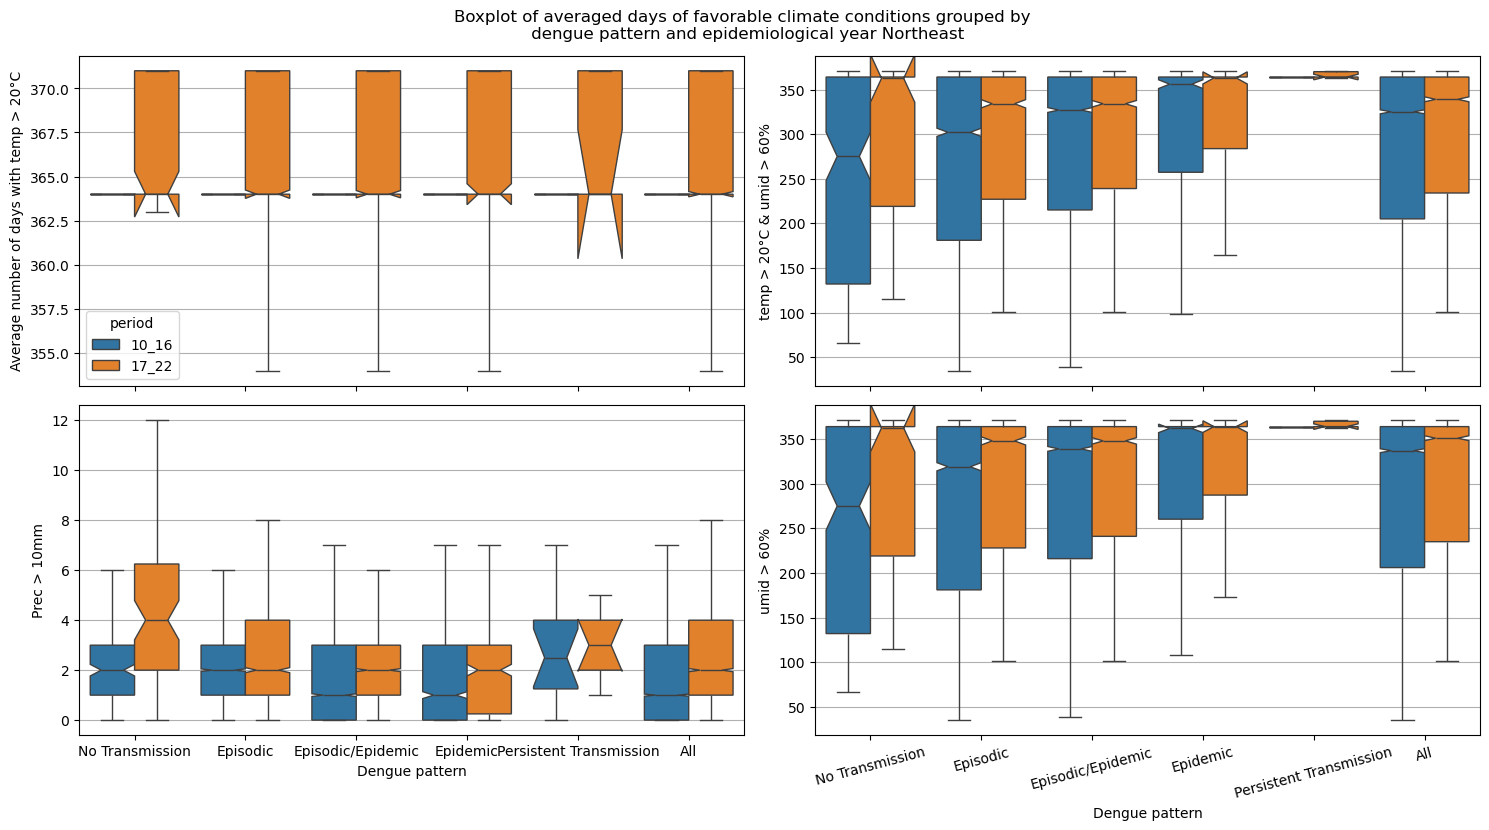

In [23]:
make_box_thr(df, region='Northeast')

In [24]:
df.loc[df.thr_temp >365].year.unique()

array([2014, 2020])

In [25]:
df_trans = pd.read_csv('../Determinantes/Dengue/transicao_new.csv', sep = ';')

rename_trans = {'Piorou':'Worsened', 'Se manteve': 'No change', 'Melhorou':'Reduce'}

df_trans['transition'] = df_trans['transition'].replace(rename_trans)

df_trans.head()

,muni_code,dengue_pattern_2010_2016,dengue_pattern_2017_2022,transition
0,1100015,Episódico/Epidêmico,Epidêmico,Worsened
1,1100023,Epidêmico,Epidêmico,No change
2,1100031,Episódico/Epidêmico,Episódico/Epidêmico,No change
3,1100049,Epidêmico,Epidêmico,No change
4,1100056,Epidêmico,Episódico/Epidêmico,Reduce


In [26]:
df_trans.transition.value_counts()

transition
No change    3893
Worsened      973
Reduce        704
Name: count, dtype: int64

In [27]:
df_trans_clima = df_17_22.merge(df_trans[['muni_code', 'transition']], left_on = 'geocodigo', right_on = 'muni_code').drop('muni_code', axis =1)

df_trans_clima.head()

,geocodigo,temp_med,umid_med,precip_tot,thr_temp,thr_umid,thr_prec,thr_temp_umid,year,dengue_pattern,period,region,transition
0,2700102,26.368572,65.759019,79.313571,371,241,0,241,2020,Episodic/Epidemic,17_22,Northeast,No change
1,2700201,25.656351,78.530554,320.167782,371,371,3,371,2020,Episodic/Epidemic,17_22,Northeast,No change
2,2700300,25.839300,73.983355,187.897610,371,366,1,366,2020,Epidemic,17_22,Northeast,No change
3,2700409,25.007031,80.555151,336.263240,371,371,3,371,2020,Episodic,17_22,Northeast,Reduce
4,2700508,25.844227,79.239810,418.317611,371,371,4,371,2020,Episodic,17_22,Northeast,No change


In [28]:
#prof_order = ['Piorou', 'Se manteve', 'Melhorou']
prof_order = ['Worsened', 'No change', 'Reduce']

In [29]:
def make_box_trans(df_trans_clima, region): 

    df_trans_clima = df_trans_clima.loc[df_trans_clima.region == region]
    
    fig, ax = plt.subplots(3,1, figsize = (9, 8),  sharex = True)
    
    sns.boxplot(x='transition', y='temp_med', data=df_trans_clima, showfliers = False, order = prof_order, ax=ax[0],
               notch = True)
    
    sns.boxplot(y='temp_med', data=df_trans_clima, showfliers = False, ax=ax[0],
               notch = True, color = 'tab:blue', legend = False)
    
    ax[0].set_ylabel('Average \n temperature')
    
    ax[0].grid(True, axis='y')
    
    
    sns.boxplot(x='transition', y='umid_med', data=df_trans_clima, showfliers = False,order = prof_order,ax=ax[1],notch = True, legend = False)
    
    sns.boxplot(y='umid_med', data=df_trans_clima, showfliers = False, ax=ax[1],
               notch = True, color = 'tab:blue', legend = False)
    
    ax[1].set_ylabel('Average \n humidity')
    
    ax[1].grid(True, axis='y')
    
    sns.boxplot(x='transition', y='precip_tot', data=df_trans_clima, showfliers = False,order = prof_order, ax=ax[2],notch = True, legend = False)
    
    sns.boxplot(y='precip_tot', data=df_trans_clima, showfliers = False, ax=ax[2],
               notch = True, color = 'tab:blue', legend = False)
    
    ax[2].set_ylabel('Total \n precipitation')
    
    ax[2].grid(True, axis='y')
    
    
    plt.suptitle(f'Boxplot of climatic variables grouped by \n dengue pattern and epidemiological year - {region}')
    
    for ax_ in [ax[0], ax[1], ax[2]]:
    
        ax_.set_xticklabels(list(prof_order) + ['All'])
        ax_.set_xlabel('Transition')
    
    
    plt.tight_layout()
    plt.xticks(rotation=15)  # Rotate x labels if needed

    plt.savefig(f'../figures/boxplot_clima_trans_{region}.png',  dpi = 450, bbox_inches = 'tight')
    plt.show()

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


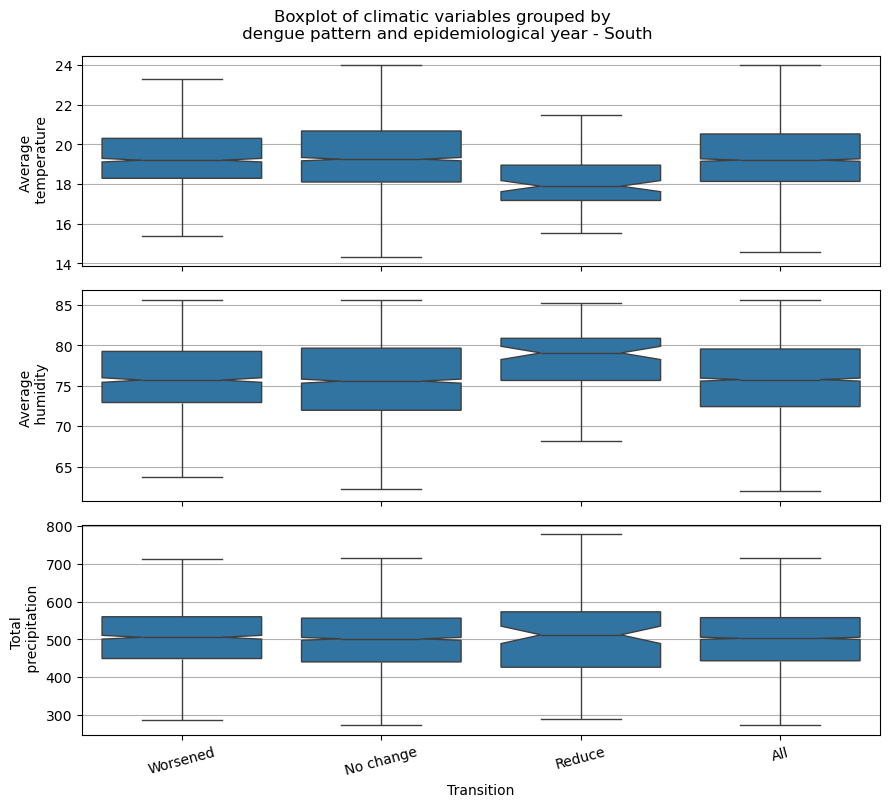

In [30]:
make_box_trans(df_trans_clima, region = 'South')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


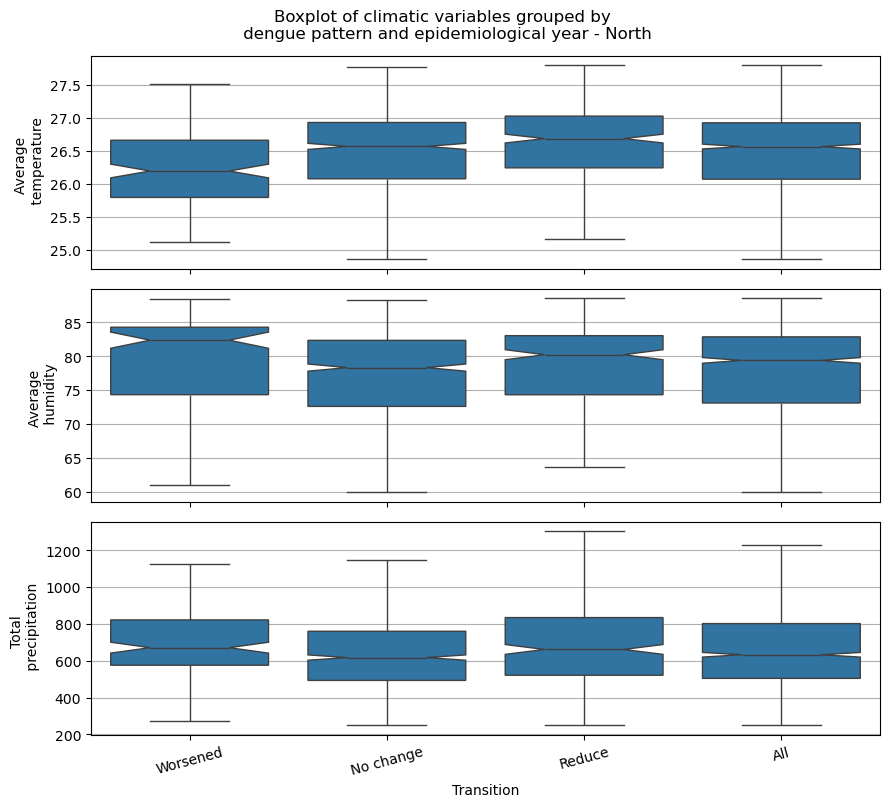

In [31]:
make_box_trans(df_trans_clima, region = 'North')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


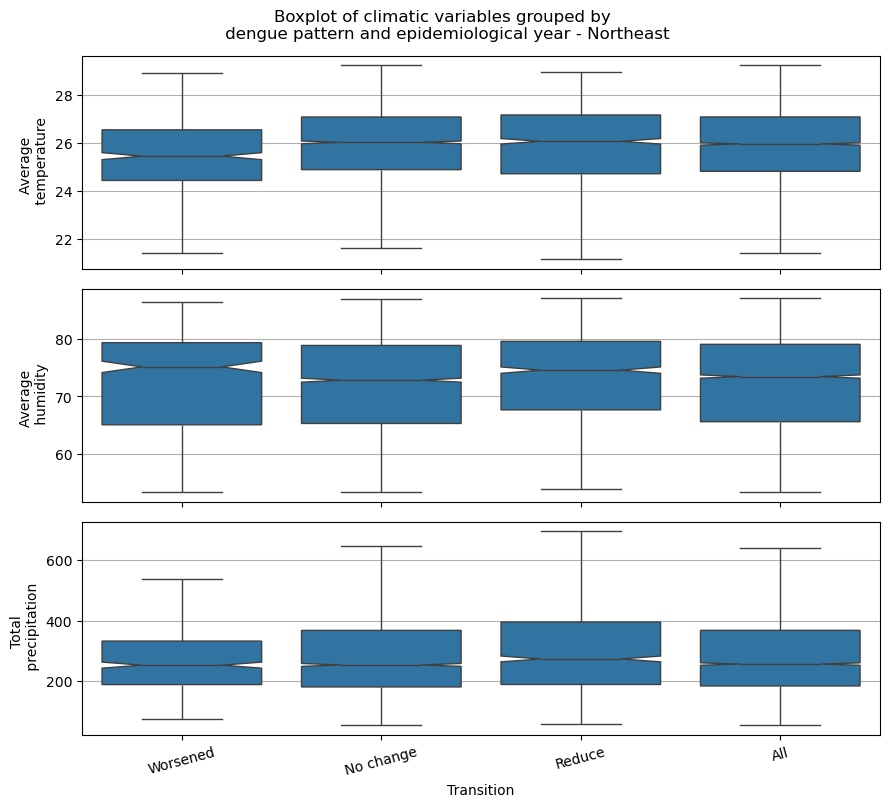

In [32]:
make_box_trans(df_trans_clima, region = 'Northeast')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


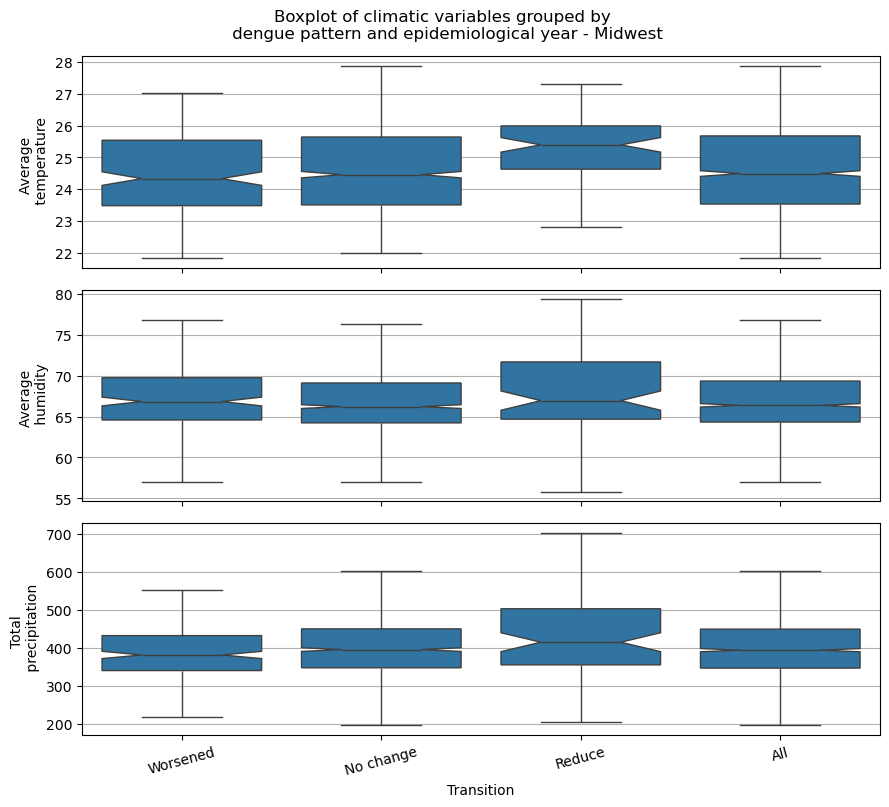

In [33]:
make_box_trans(df_trans_clima, region = 'Midwest')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/2694306711.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])


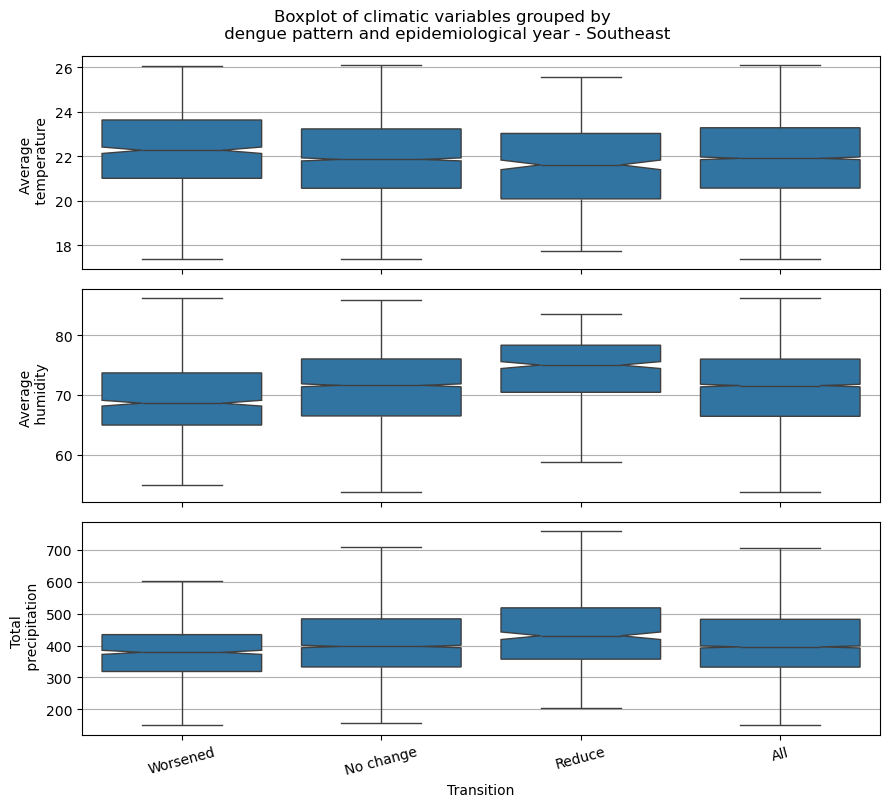

In [34]:
make_box_trans(df_trans_clima, region = 'Southeast')

In [35]:
def make_box_trans_thr(df_trans_clima, region):

    df_trans_clima = df_trans_clima.loc[df_trans_clima.region == region]
    
    fig, ax = plt.subplots(2,2, figsize = (15, 8),  sharex = True)

    sns.boxplot(x='transition', y='thr_temp', data=df_trans_clima, showfliers = False, order = prof_order, ax=ax[0,0],
               notch = True)
    
    sns.boxplot(y='thr_temp', data=df_trans_clima, showfliers = False,  ax=ax[0,0],
               notch = True, color = 'tab:blue', legend = False)
    
    ax[0,0].set_ylabel('Average number of days with temp > 20°C ')
    
    
    sns.boxplot(x='transition', y='thr_temp_umid', data=df_trans_clima, showfliers = False,order = prof_order,  ax=ax[0, 1],
                legend = False, notch = True)
    
    sns.boxplot(y='thr_temp_umid', data=df_trans_clima, showfliers = False,  ax=ax[0,1],
               notch = True, color = 'tab:blue', legend = False)
    
    ax[0, 1].set_ylabel('temp > 20°C & umid > 60%')
    
    
    sns.boxplot(x='transition', y='thr_prec', data=df_trans_clima, showfliers = False,order = prof_order, ax=ax[1,0],
                legend = False, notch = True)
    
    sns.boxplot(y='thr_prec', data=df_trans_clima, showfliers = False, ax=ax[1,0],
               notch = True, color = 'tab:blue', legend = False)
    
    ax[1,0].set_ylabel('Prec > 10mm')
    
    sns.boxplot(x='transition', y='thr_umid', data=df_trans_clima, showfliers = False,order = prof_order, ax=ax[1,1],
                legend = False, notch = True)
    
    sns.boxplot(y='thr_umid', data=df_trans_clima, showfliers = False, ax=ax[1,1],
               notch = True, color = 'tab:blue', legend = False)
    
    ax[1,1].set_ylabel('umid > 60%')
    
    for ax_ in ax.ravel():
        ax_.grid(True, axis='y')
        ax_.set_xticklabels(list(prof_order) + ['All'])
        
    plt.suptitle(f'Boxplot of averaged days of favorable climate conditions grouped by \n dengue pattern and epidemiological year {region}')
    
    plt.tight_layout()
    plt.xticks(rotation=15)  # Rotate x labels if needed
    
    plt.savefig(f'../figures/boxplot_thr_clima_trans_{region}.png',  dpi = 300, bbox_inches = 'tight')
    plt.show()


/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.

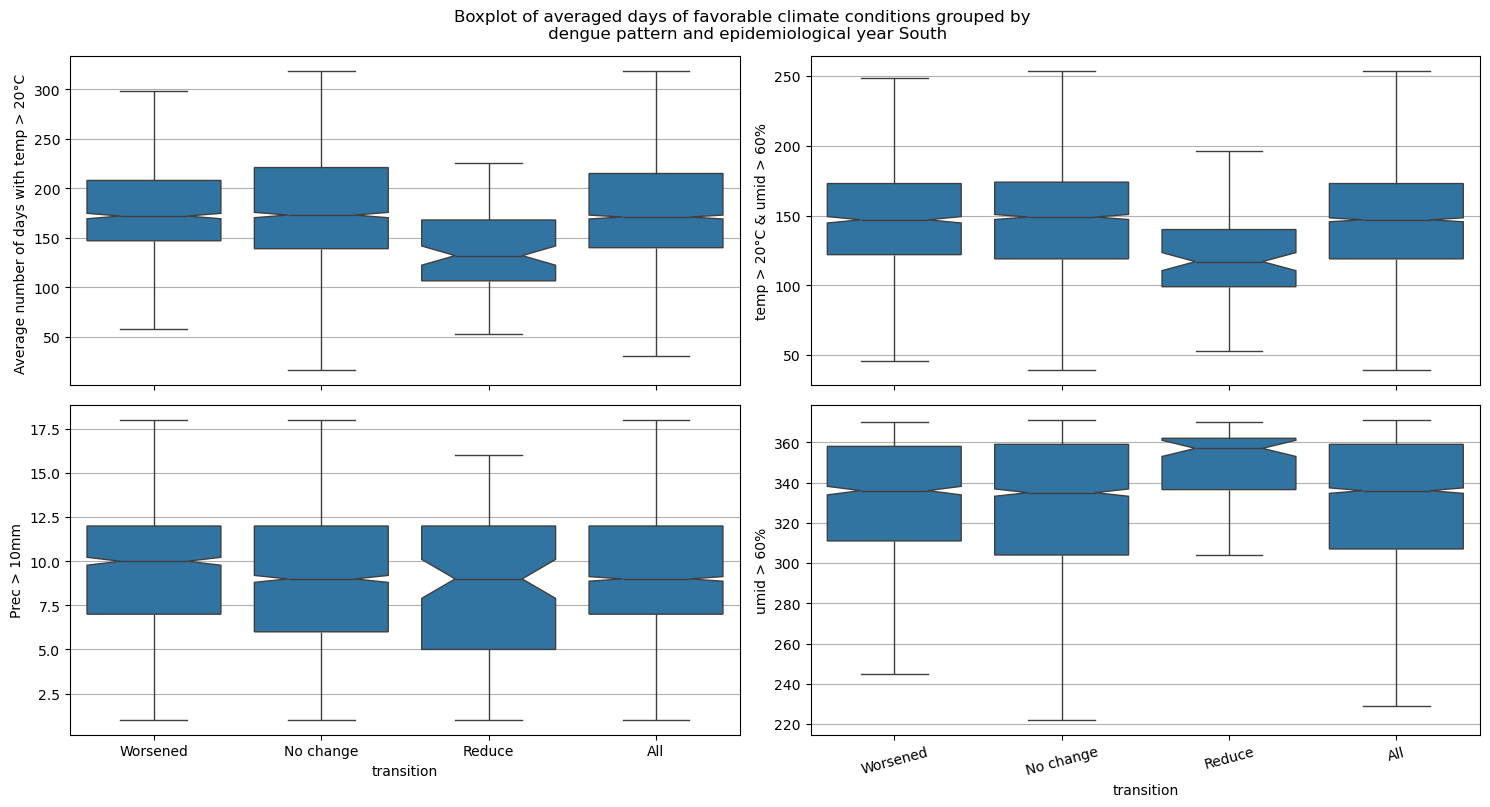

In [36]:
make_box_trans_thr(df_trans_clima, region = 'South')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.

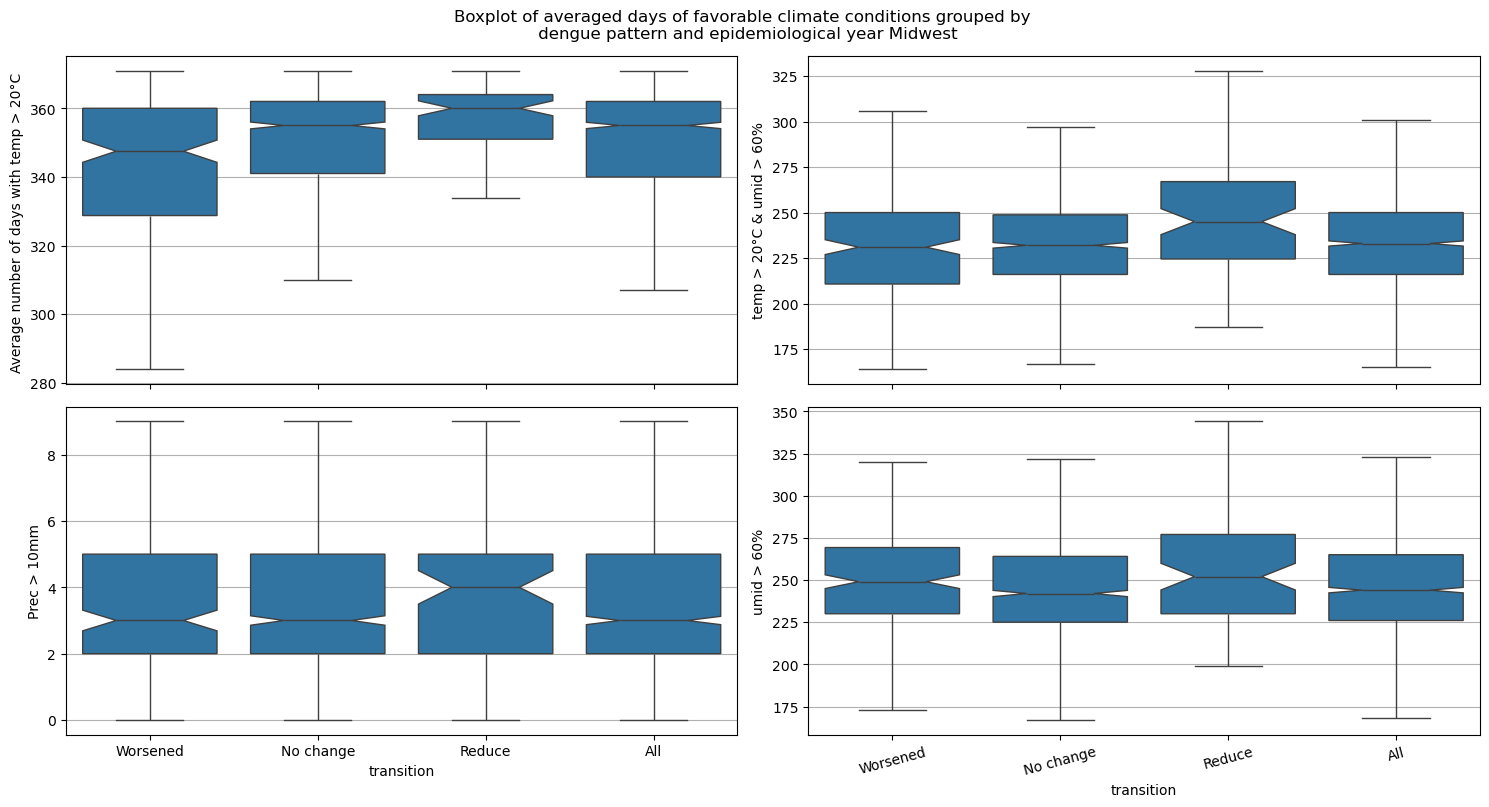

In [37]:
make_box_trans_thr(df_trans_clima, region = 'Midwest')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.

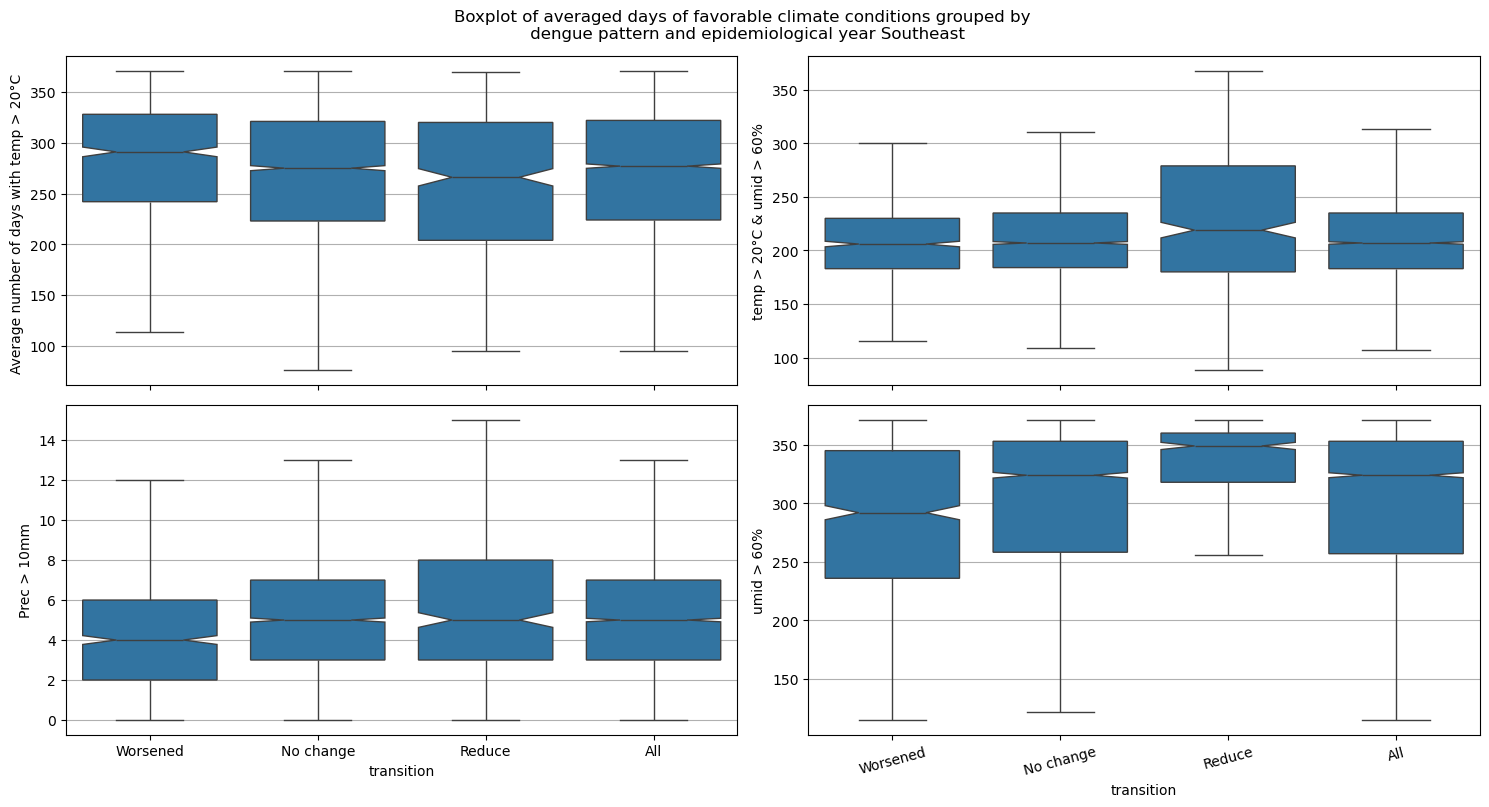

In [38]:
make_box_trans_thr(df_trans_clima, region = 'Southeast')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.

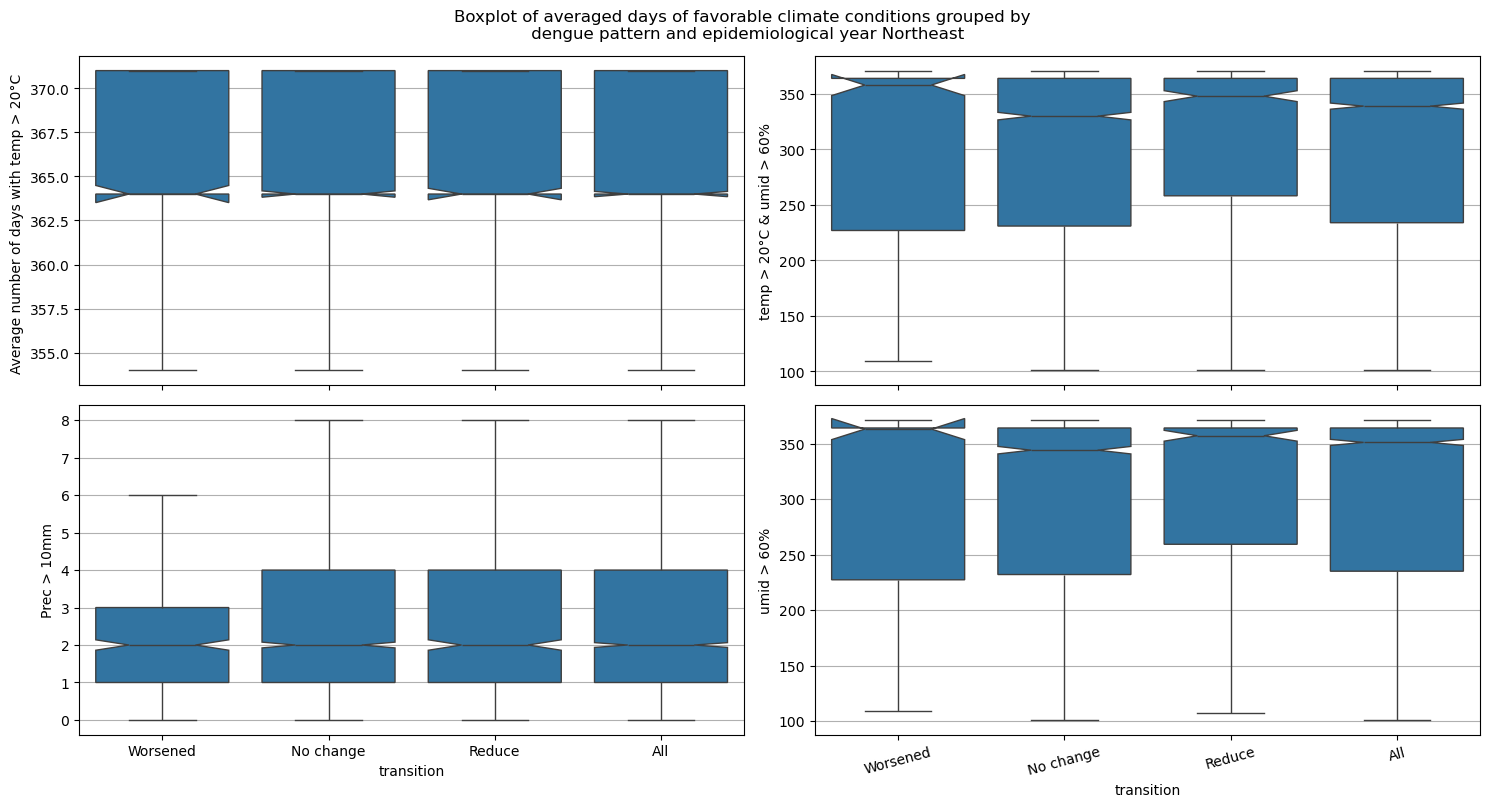

In [39]:
make_box_trans_thr(df_trans_clima, region = 'Northeast')

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.set_xticklabels(list(prof_order) + ['All'])
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_11711/3365924079.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_.

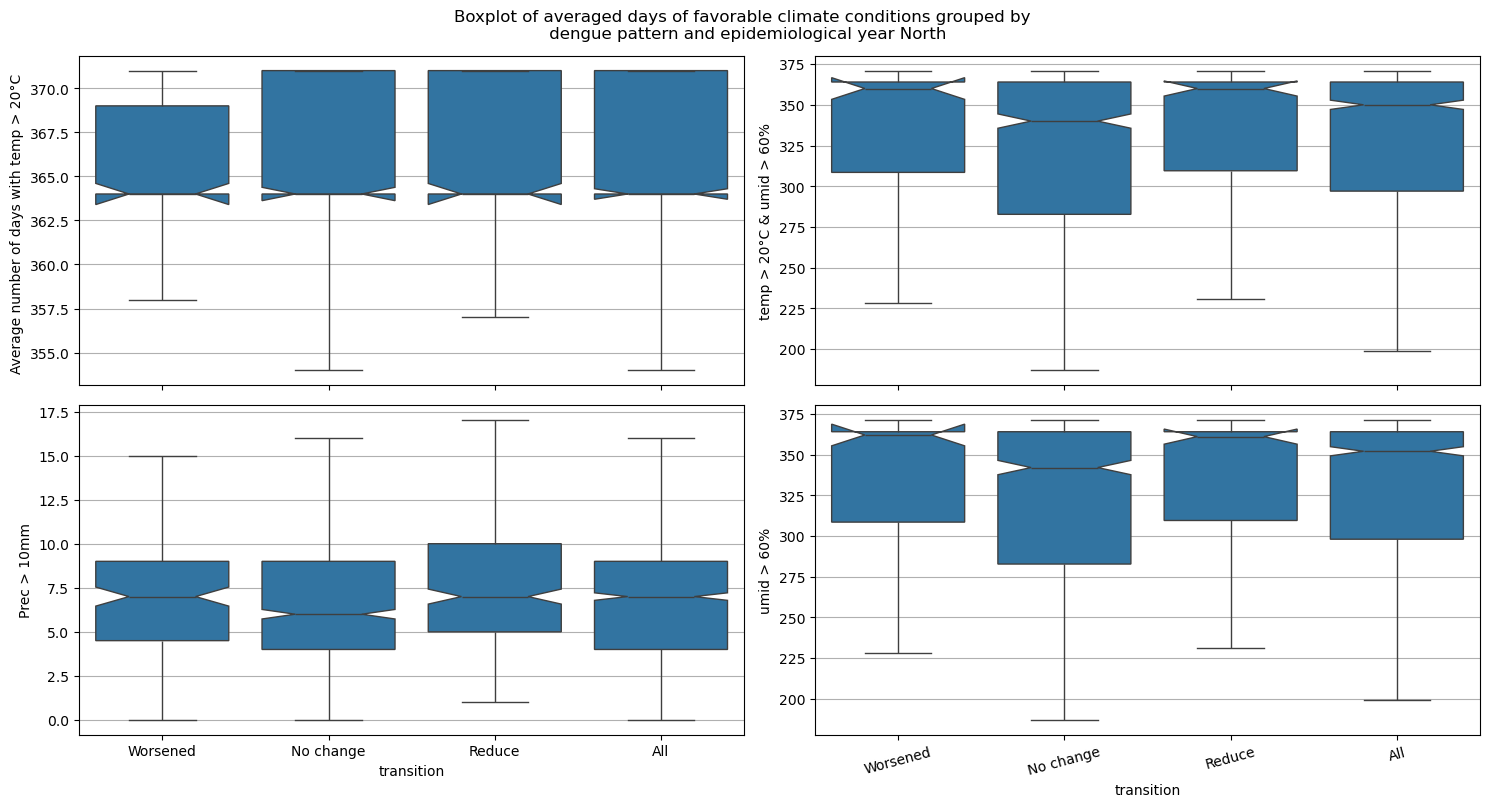

In [40]:
make_box_trans_thr(df_trans_clima, region = 'North')